In [2]:
import xgboost as xgb
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path
import numpy as np

In [ ]:
model = xgb.XGBRegressor()
# model.load_model("/scratch/er8/cd3022/xgb_models/test_model.json")
model.load_model("/scratch/er8/cd3022/xgb_models/radiance_model.json")

data = pd.read_parquet('/scratch/er8/cd3022/xgb_datasets/syd_radiances_2025-01-01+5.parquet')

X = data.drop(columns=['surface_global_irradiance'])
for n in range(1, 11):
    X = X.drop(columns=[f'surface_global_irradiance_t{n}'])
y = data['surface_global_irradiance_t6']

df = X.join(y)
df['surface_global_irradiance'] = data['surface_global_irradiance']
df['forecast_t6'] = model.predict(X)

ds_xgb = df.to_xarray()

In [ ]:
def file_name_to_datetime64(file_path):
    '''
    Convert string from file name into np.datetime64 to be assigned as new coordinate to dataset.
    Assumes filename is in the format ".../YYYYmmddTHHMM..."
    
    INPUTS
    file_path (PosixPath): path to the file

    OUTPUTS
    np.datetime64 corresponding to the file name
    '''
    time_str = file_path.stem
    
    year = time_str[0:4]
    month = time_str[4:6]
    day = time_str[6:8]
    hour = time_str[9:11]
    minute = time_str[11:13]

    return np.datetime64(f'{year}-{month}-{day}T{hour}:{minute}')

def preprocess(ds):
    # Extract filename from encoding
    file_path = Path(ds.encoding["source"])
    
    # Add new "time" dimension
    t = file_name_to_datetime64(file_path)
    
    return (
        ds
        .rename({'time': 'forecast_time'})
        .expand_dims(time=[t])
        .sel(
            latitude=ds_xgb.latitude,
            longitude=ds_xgb.longitude
        )
    )

In [ ]:
gso_path = Path('/scratch/er8/mm4602/gso/output/nwc_20240701_20251231/2025/01/01')
gso_files = [f for f in gso_path.glob('*.nc')]

ds_gso = xr.open_mfdataset(
    gso_files,
    preprocess=preprocess,
    combine='nested',
    concat_dim='time',
    parallel=True,
    chunks='auto'
)

Text(0.5, 1.0, 'XGB forecast t60min')

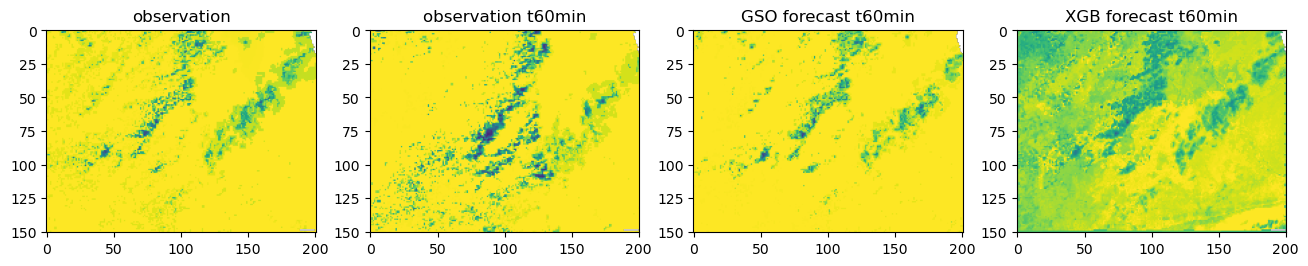

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16,10))
time= '2025-01-01T01:00'
f_time= '2025-01-01T02:00'


ax[0].imshow(
    ds_xgb.surface_global_irradiance.sel(time=time),
    vmin=0, vmax=1000
)
ax[1].imshow(
    ds_xgb.surface_global_irradiance_t6.sel(time=time),
    vmin=0, vmax=1000
)

ax[2].imshow(
    ds_gso.surface_global_irradiance.sel(time=time, forecast_time=f_time),
    vmin=0, vmax=1000
)

ax[3].imshow(
    ds_xgb.forecast_t6.sel(time=time),
    vmin=0, vmax=1000
)

ax[0].set_title('observation')
ax[1].set_title('observation t60min')
ax[2].set_title('GSO forecast t60min')
ax[3].set_title('XGB forecast t60min')